# **Seasonal Agriculture Performance Analysis**


**Introduction**

Agricultural performance is shaped by the season in which a crop is grown — India's three cropping seasons are Kharif (monsoon-sown, June–Oct), Rabi (winter-sown, Oct–Mar) and Zaid (short summer season, Mar–June). Each season brings different rainfall, temperature and water-availability patterns, which in turn affect yield, cost, and profitability.

This notebook analyzes 4,000 farm-level records spanning 8 states, 8 crops and 4 irrigation methods to understand how agricultural performance varies across seasons, and to surface evidence-based patterns that could support seasonal agricultural planning.

**Problem Statement**

  Agricultural activities are influenced by seasonal variations in environmental conditions, 
farming practices, resource availability and market conditions. As a result, agricultural 
performance may differ from one season to another. 
However, raw agricultural data does not clearly explain how agricultural performance changes 
across seasons or what patterns can be observed in different seasonal conditions. 
The problem is to analyze the given agricultural dataset and investigate seasonal differences 
in agricultural performance by identifying meaningful patterns, trends, relationships and 
variations within the available data. 

**Objective**
  
* Explore, clean and prepare the dataset for analysis
* Examine how yield, cost, revenue and profit vary across seasons
* Investigate relationships between seasonal environmental conditions (rainfall, temperature, soil, water use) and outcomes
* Compare crops, states and irrigation methods across seasons
* Identify significant differences, unusual patterns and outliers
* Derive evidence-based insights and recommendations for seasonal planning

## **Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")

In [2]:
df=pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [3]:
print("Shape:", df.shape)

Shape: (4000, 28)


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [9]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum()>0])

print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64
Duplicate rows: 0


In [10]:
cols = ['State', 'Season', 'Crop', 'Irrigation_Method']

for col in cols:
    print(f"\n{col} ({df[col].nunique()} unique values)")
    print(df[col].value_counts())


State (8 unique values)
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Season (3 unique values)
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crop (8 unique values)
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation_Method (4 unique values)
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


**Observations:**
* Size: 4,000 records, 28 columns
* Duplicates: None — every row is unique
*  Only three columns have missing values:
1. Rainfall_mm → 48 missing 
2. Soil_Moisture_pct → 40 missing
3. Yield_Tonnes_Ha → 32 missing (all under 1.5% of rows, so they can be safely imputed rather than dropped.)
* 3 seasons (Kharif, Rabi, Zaid), 8 crops, 8 states, 4 irrigation methods

## **Data Cleaning & Preparation**

In [11]:
# Impute missing numeric values with the season-wise median
columns = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for column in columns:
    median = df.groupby('Season')[column].transform('median')
    df[column] = df[column].fillna(median)

print("Missing values left:", df.isnull().sum().sum())

Missing values left: 0


In [12]:
# Check for impossible / negative values in key numeric columns
num_cols = ['Farm_Area_Hectares','Rainfall_mm','Yield_Tonnes_Ha','Production_Tonnes',
            'Total_Cost_INR','Revenue_INR','Water_Used_m3']
print(df[num_cols].min())

Farm_Area_Hectares        0.50
Rainfall_mm              80.00
Yield_Tonnes_Ha           0.30
Production_Tonnes         0.15
Total_Cost_INR        26826.00
Revenue_INR            6107.00
Water_Used_m3           128.00
dtype: float64


In [13]:
# Find yield outliers for each crop
def find_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    
    IQR = Q3 - Q1
    
    return (data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)

outlier_flags = df.groupby('Crop')['Yield_Tonnes_Ha'].transform(find_outliers)

print("Number of yield outliers:", outlier_flags.sum())

df['Yield_Outlier'] = outlier_flags

Number of yield outliers: 2


In [14]:
print("Outliers:", outlier_flags.sum())
print("Percentage:", round(outlier_flags.mean() * 100, 2), "%")

Outliers: 2
Percentage: 0.05 %


## **Seasonal Overview**

In [15]:
# Group the data by Season
season_summary = df.groupby('Season').agg({
    'Farm_ID': 'count',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

season_summary = season_summary.round(1)

season_summary = season_summary.sort_values('Profit_INR', ascending=False)
season_summary

,Farm_ID,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,1779,852.1,28.5,5.6,178914.6,6102.2,54.5
Rabi,1627,435.9,23.5,5.0,87689.5,5847.0,40.5
Zaid,594,299.1,31.0,4.6,-24804.8,6419.9,38.2


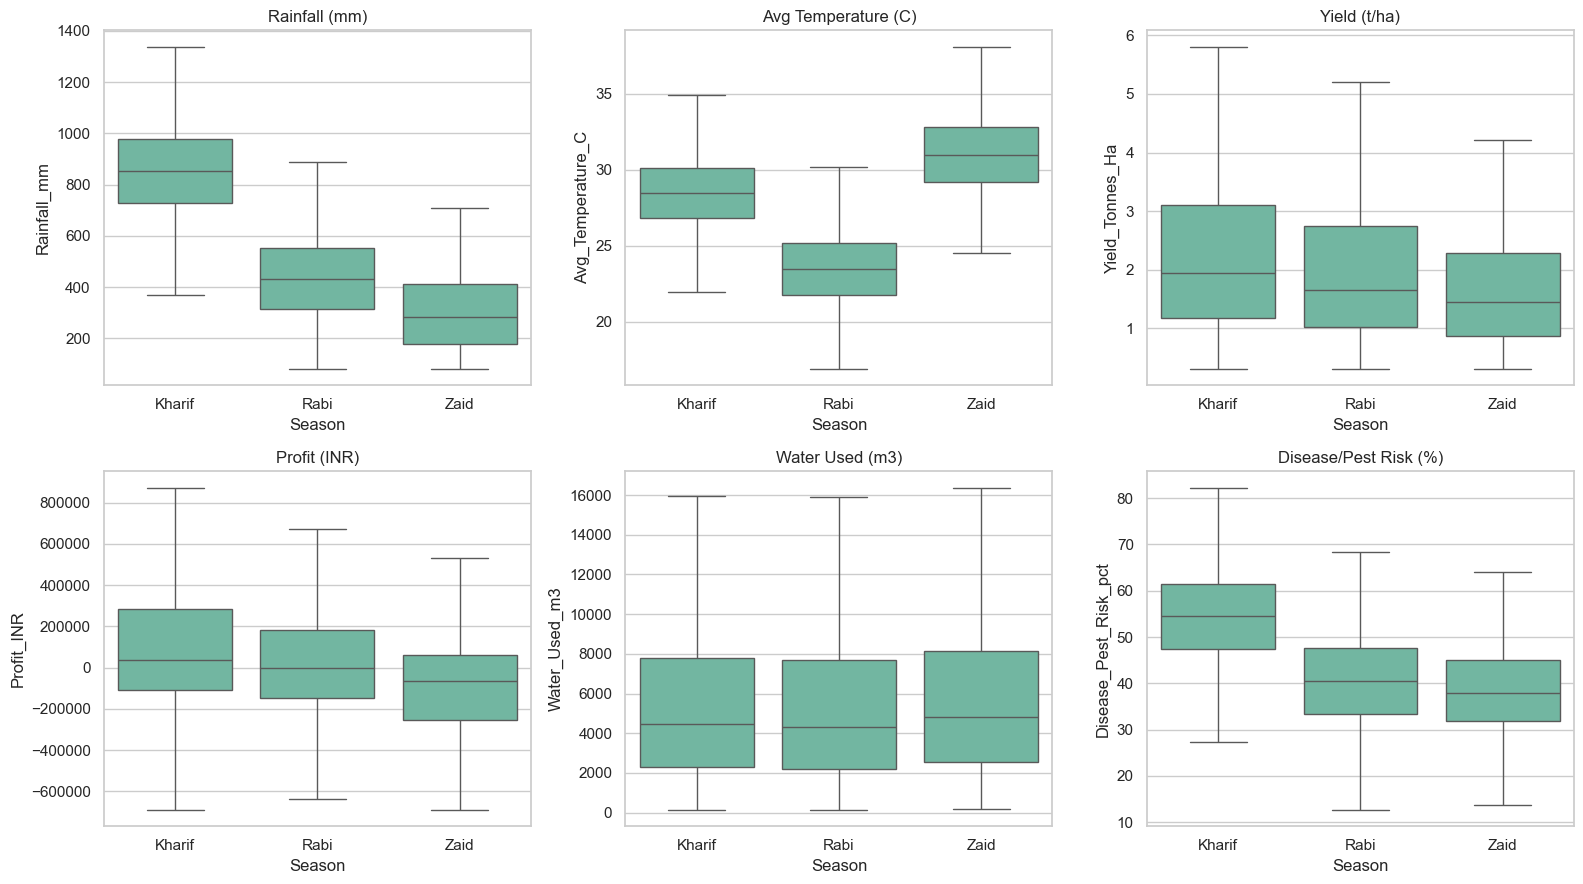

In [16]:
order = ['Kharif', 'Rabi', 'Zaid']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Rainfall
sns.boxplot(data=df, x='Season', y='Rainfall_mm',
            order=order, ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title('Rainfall (mm)')

# 2. Temperature
sns.boxplot(data=df, x='Season', y='Avg_Temperature_C',
            order=order, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title('Avg Temperature (C)')

# 3. Yield
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha',
            order=order, ax=axes[0, 2], showfliers=False)
axes[0, 2].set_title('Yield (t/ha)')

# 4. Profit
sns.boxplot(data=df, x='Season', y='Profit_INR',
            order=order, ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title('Profit (INR)')

# 5. Water
sns.boxplot(data=df, x='Season', y='Water_Used_m3',
            order=order, ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title('Water Used (m3)')

# 6. Disease Risk
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct',
            order=order, ax=axes[1, 2], showfliers=False)
axes[1, 2].set_title('Disease/Pest Risk (%)')

plt.tight_layout()

## **Environmental Conditions by Season**

In [17]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct','Soil_pH']
env_by_season = df.groupby('Season')[env_cols].mean().round(2).loc[order]
env_by_season

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20,6.73
Rabi,435.94,23.49,57.89,7.59,24.05,6.67
Zaid,299.12,31.04,52.01,8.18,19.17,6.69


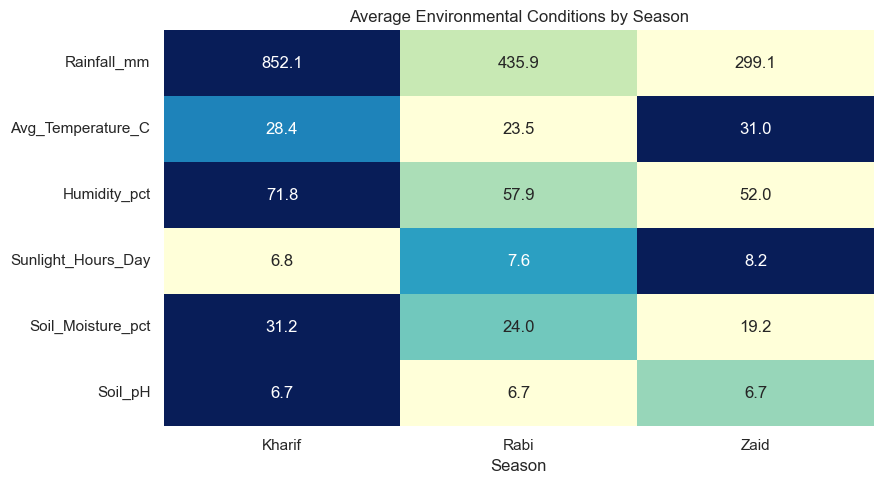

In [18]:
env_norm = (env_by_season - env_by_season.min()) / (
    env_by_season.max() - env_by_season.min()
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    env_norm.T,
    annot=env_by_season.T.round(1),
    fmt='.1f',
    cmap='YlGnBu',
    cbar=False
)

plt.title('Average Environmental Conditions by Season')
plt.tight_layout()

## **Crop Yield & Production Across Seasons**

In [19]:
yield_pivot = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean').round(2)[order]
yield_pivot

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


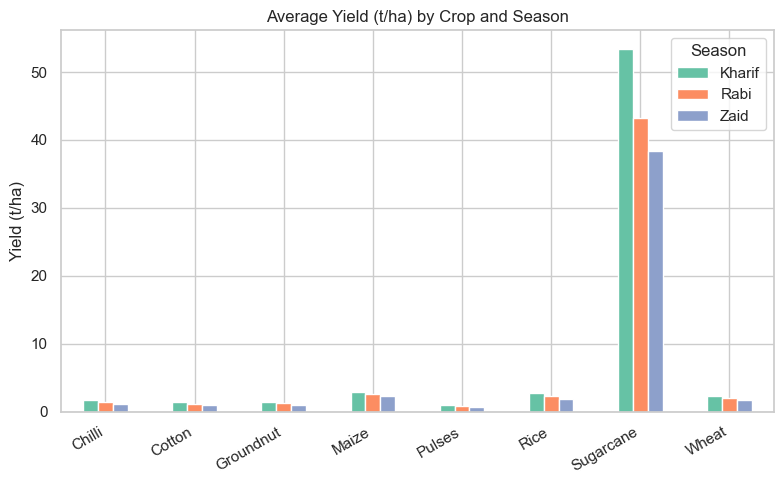

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

yield_pivot.plot(kind='bar', ax=ax)

plt.title('Average Yield (t/ha) by Crop and Season')
plt.ylabel('Yield (t/ha)')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Season')
plt.tight_layout()

## **Economic Performance Across Seasons**

In [21]:
econ_cols = ['Total_Cost_INR','Revenue_INR','Profit_INR']
econ_by_season = df.groupby('Season')[econ_cols].mean().round(0).loc[order]
econ_by_season['Profit_Margin_pct'] = (econ_by_season['Profit_INR'] / econ_by_season['Revenue_INR'] * 100).round(1)
econ_by_season

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.0,710719.0,178915.0,25.2
Rabi,513837.0,601526.0,87689.0,14.6
Zaid,543977.0,519172.0,-24805.0,-4.8


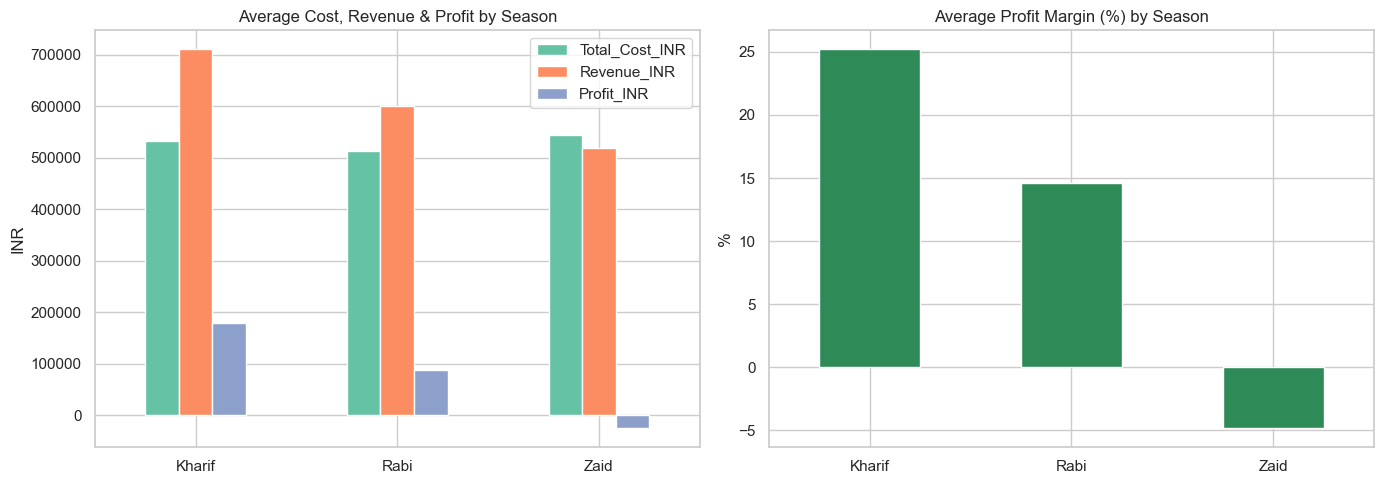

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

econ_by_season[['Total_Cost_INR','Revenue_INR','Profit_INR']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Cost, Revenue & Profit by Season')
axes[0].set_ylabel('INR')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

econ_by_season['Profit_Margin_pct'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Average Profit Margin (%) by Season')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()

Share of loss-making farms by season — a useful, more concrete indicator than the mean alone, since profit is heavily right-skewed.

In [23]:
loss_share = df.groupby('Season')['Profit_INR'].apply(lambda x: (x < 0).mean() * 100)
loss_share = loss_share.round(1).loc[order]
loss_share.rename('Loss_Making_Farms_pct')

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Loss_Making_Farms_pct, dtype: float64

## **Resource Usage & Water Efficiency Across Seasons**

In [24]:
resource_cols = ['Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3','Water_Efficiency_t_per_1000m3']
resource_by_season = df.groupby('Season')[resource_cols].mean().round(2).loc[order]
resource_by_season

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


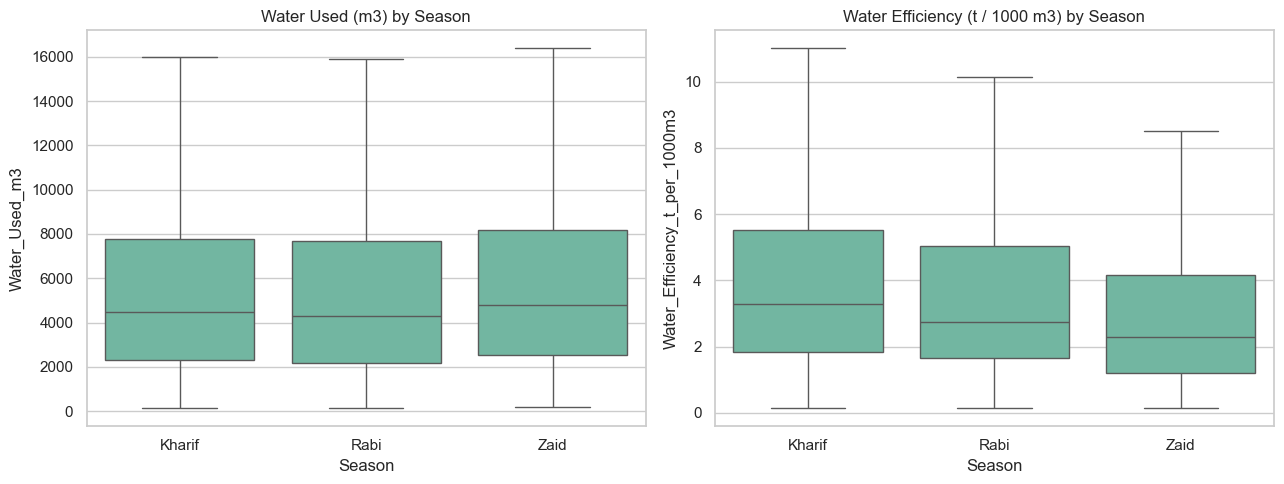

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='Season', y='Water_Used_m3', order=order, ax=axes[0], showfliers=False)
axes[0].set_title('Water Used (m3) by Season')

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=order, ax=axes[1], showfliers=False)
axes[1].set_title('Water Efficiency (t / 1000 m3) by Season')

plt.tight_layout()

In [26]:
irr_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').round(3) * 100
irr_season = irr_season.loc[order]
irr_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


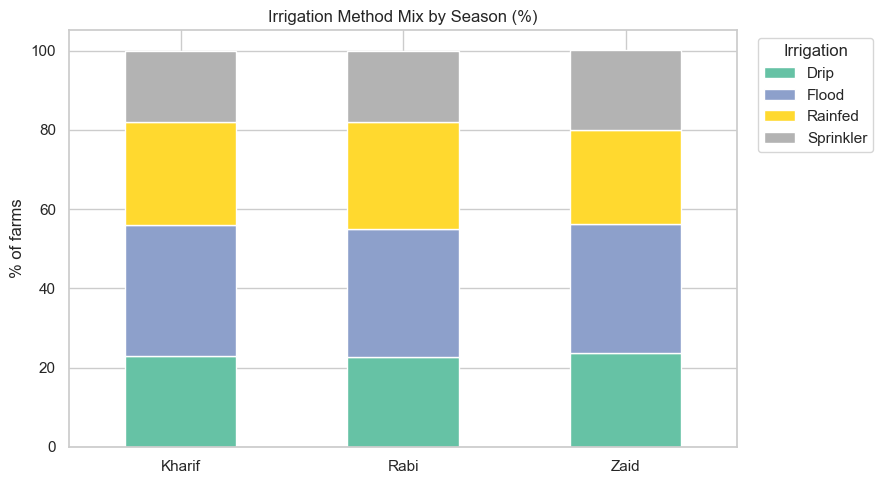

In [27]:
irr_season.plot(kind='bar', stacked=True, figsize=(9,5), colormap='Set2')
plt.title('Irrigation Method Mix by Season (%)')
plt.ylabel('% of farms')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Irrigation', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()

## **Disease & Pest Risk Across Seasons**

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


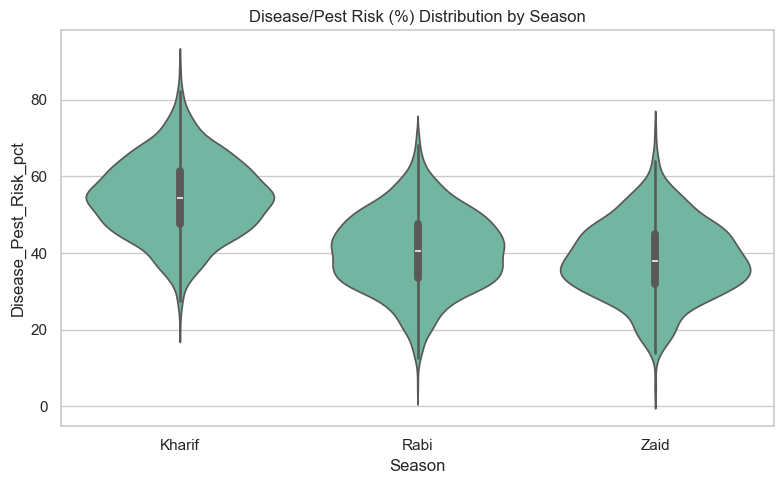

In [28]:
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=order, ax=ax)
plt.title('Disease/Pest Risk (%) Distribution by Season')
plt.tight_layout()

print(df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2).loc[order])

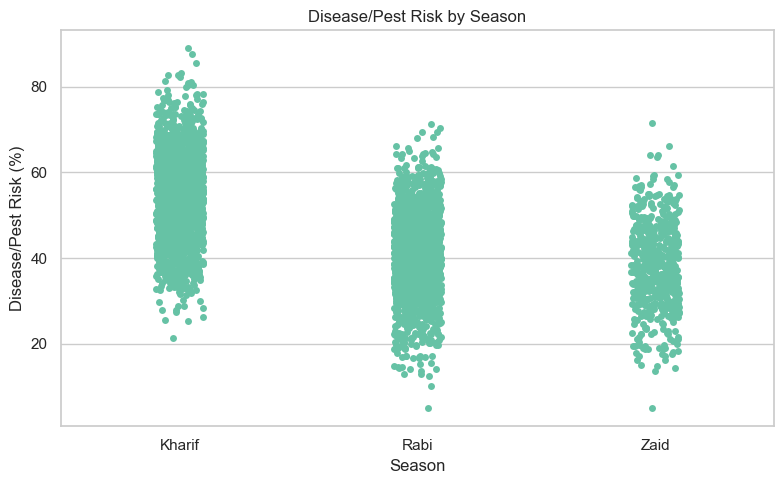

In [29]:
plt.figure(figsize=(8,5))

sns.stripplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct',
    order=order,
    jitter=True
)

plt.title('Disease/Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout()

## **Correlation Analysis**

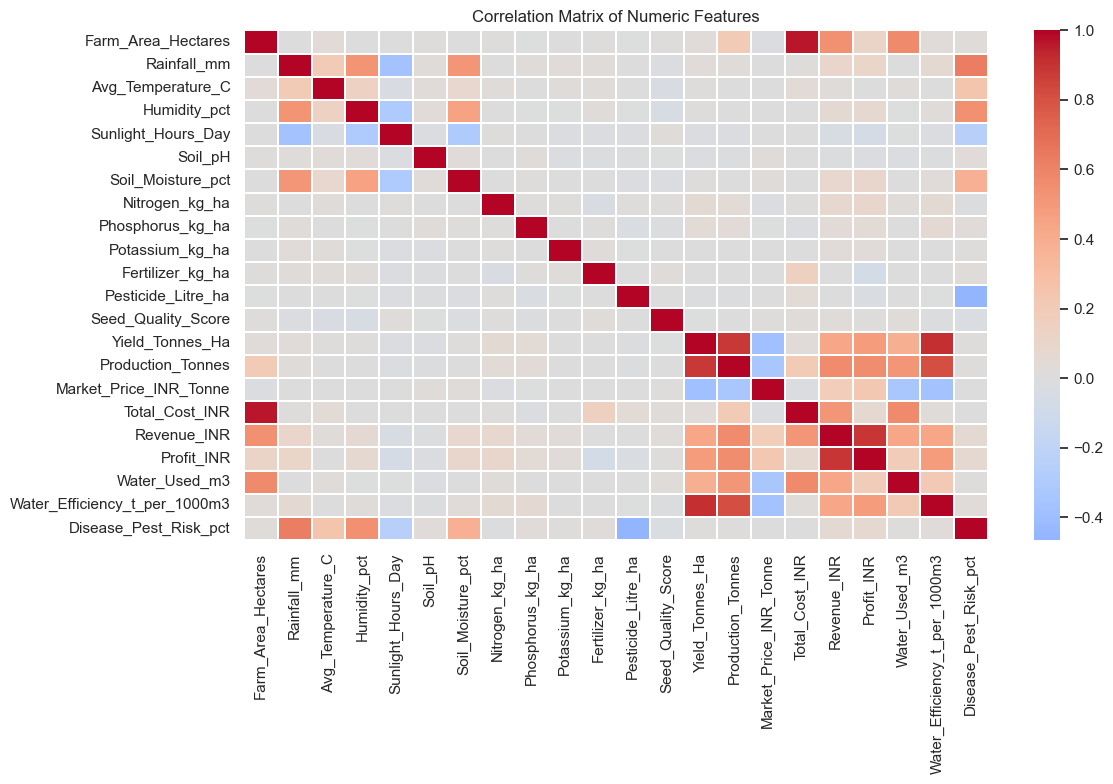

In [30]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop('Yield_Outlier', errors='ignore')
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3, ax=ax)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()

In [31]:
print("Strongest correlations with Profit_INR:")
print(corr['Profit_INR'].drop('Profit_INR').sort_values(ascending=False))
print()
print("Strongest correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False))

Strongest correlations with Profit_INR:
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488459
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.106117
Soil_Moisture_pct                0.092436
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64

Strongest correlations with Yield_Tonnes_Ha:

## **Statistical Testing: Is the Seasonal Difference Significant?**

We use a one-way ANOVA to test whether the mean differs significantly across the three seasons (Kharif, Rabi, Zaid) for the key outcome variables. The null hypothesis (H0) is that all three season means are equal.

In [32]:
anova_targets = [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct',
    'Rainfall_mm',
    'Avg_Temperature_C'
]

results = []

for col in anova_targets:
    groups = [df[df['Season'] == s][col].dropna() for s in order]
    f, p = stats.f_oneway(*groups)

    results.append({
        'Metric': col,
        'F-statistic': round(f, 2),
        'p-value': round(p, 5),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })

anova_df = pd.DataFrame(results)

anova_df

,Metric,F-statistic,p-value,Significant (p<0.05)
0,Yield_Tonnes_Ha,1.55,0.21156,No
1,Profit_INR,34.29,0.00000,Yes
2,Water_Used_m3,2.47,0.08501,No
3,Disease_Pest_Risk_pct,1049.47,0.00000,Yes
4,Rainfall_mm,3449.40,0.00000,Yes
5,Avg_Temperature_C,2678.74,0.00000,Yes


A p-value below 0.05 means the differences observed across seasons are statistically significant and unlikely to be due to random chance.

## **State-wise and Crop-wise Seasonal Patterns**

In [33]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean').round(0)[order]
state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


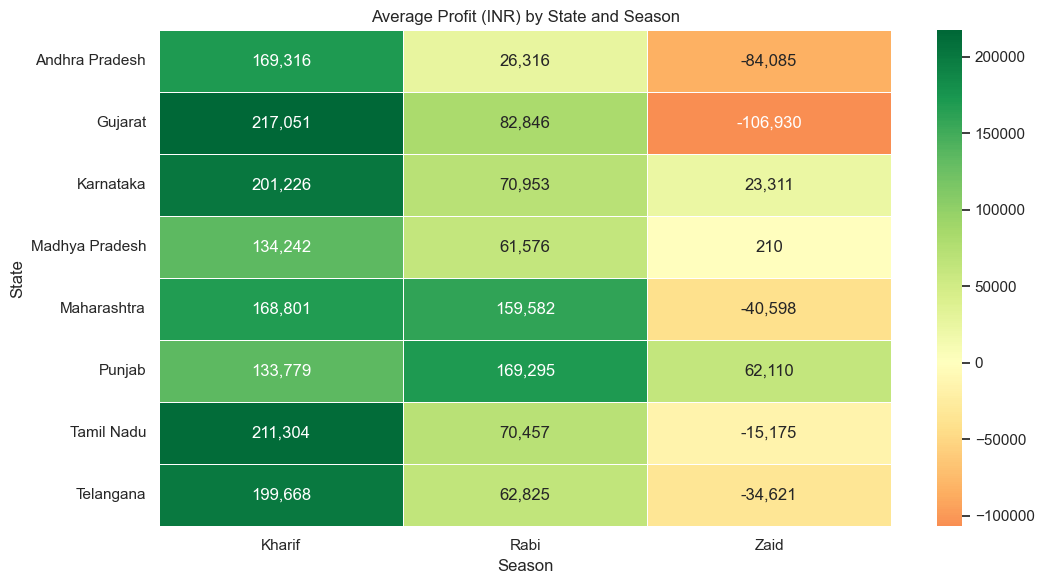

In [34]:
fig, ax = plt.subplots(figsize=(11,6))
sns.heatmap(state_season_profit, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit (INR) by State and Season')
plt.tight_layout()

In [35]:
crop_season_counts = pd.crosstab(df['Crop'], df['Season'])[order]
print("Which crops are grown in which seasons (farm count):")
crop_season_counts

Which crops are grown in which seasons (farm count):


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


## **Key Findings**

1. **Rainfall and temperature are very different in each season.**
   Kharif gets the most rain, about **852 mm**. Rabi gets around **436 mm**, while Zaid gets only about **299 mm**. Zaid is also the hottest season, with an average temperature of about **31°C**.

2. **Season does not have a big effect on yield.**
   The ANOVA test gives a p-value of **0.21**, so the difference in yield between seasons is not significant. The type of crop may have a bigger effect on yield than the season.

3. **Profit changes a lot between seasons.**
   Kharif has the highest average profit of about **₹1,78,915**. Rabi has around **₹87,690**, while Zaid has an average **loss of ₹24,805**.

4. **Zaid is the riskiest season for farmers.**
   Around **64.5% of Zaid farms are making a loss**. This is higher than Rabi (**51.1%**) and Kharif (**42.2%**). The low rainfall in Zaid may increase the need for irrigation and increase costs.

5. **Disease and pest risk is highest in Kharif.**
   Kharif has about **54.5% risk**, compared with **40.5% in Rabi** and **38.2% in Zaid**. The rainy and humid weather in Kharif may be one reason for the higher risk.

6. **Total water use is almost similar across seasons.**
   The test shows no significant difference in total water usage. However, farmers use different water sources. Zaid depends more on **drip and sprinkler irrigation** because it receives less rain, while Kharif gets more help from rainfall.

### Simple Conclusion

Overall, **season affects profit and risk more than it affects yield**.
**Kharif is the most profitable season**, although it has higher disease and pest risk. **Zaid is the hottest, driest, and riskiest season**, with the highest percentage of farms making a loss.


## **Recommendations**

* **Give more attention to Zaid season:** Zaid has the highest number of farms making a loss (**64.5%**) and also has a negative average profit. Farmers may need better irrigation support, affordable seeds and other inputs, or guidance on choosing crops that are more suitable for Zaid.

* **Prepare more for pests and diseases in Kharif:** Kharif has the highest disease and pest risk (**54.5%**), compared with **40.5% in Rabi** and **38.2% in Zaid**. Farmers should be more prepared for pest and disease problems during Kharif.

* **Focus on profit, not only yield:** The analysis shows that yield does not change much between seasons, but profit changes a lot. So, farmers should focus not only on producing more crops, but also on **reducing costs and getting better prices for their crops**.

* **Use irrigation carefully in Zaid:** Zaid gets very little rainfall, so farmers depend more on irrigation such as drip and sprinkler systems. Since Zaid is still less profitable, it is important to find ways to **reduce water costs and use water more efficiently**.


## **Key Questions**

**Overall Finding**

Seasonality has a much stronger effect on farm profitability, financial risk, and environmental conditions than on crop production itself. Yield remains relatively stable across seasons, while profit changes dramatically.

**1. How does agricultural performance vary across seasons?**

Crop yield remains roughly similar across all three seasons, meaning the season does not strongly affect how much farmers produce. However, profitability varies significantly. **Kharif** records the highest average profit at approximately **₹1.79 lakh**, followed by **Rabi** at around **₹87,700**. **Zaid** performs the weakest, with an average loss of approximately **₹24,800**.


**2. What major seasonal patterns can be observed?**

Each season has a distinct agricultural profile. **Kharif** is wetter and more humid, resulting in the highest profitability but also the highest disease and pest risk. **Rabi** provides relatively cool and stable conditions with moderate profitability. **Zaid** is the hottest and driest season, has fewer participating farms, and records the highest financial losses.


**3. Which characteristics change between seasons?**

Environmental characteristics such as **rainfall, temperature, and humidity** change substantially between seasons. Profitability and disease/pest risk also show clear seasonal differences. In contrast, **crop yield and water usage remain relatively stable**, suggesting that these factors may depend more on crop type and farming practices than on season alone.


**4. What differences exist between agricultural activities in different seasons?**

All major crops are cultivated across the three seasons, but participation in **Zaid is considerably lower**. For example, substantially more farms grow Rice during Kharif than during Zaid. This indicates that Zaid is a smaller and potentially riskier farming period in which fewer farmers participate.


**5. Are there noticeable variations in resource usage across seasons?**

Surprisingly, resource usage does not change as much as expected. Despite Zaid receiving considerably less rainfall than Kharif, the **overall irrigation-method mix remains broadly similar** across seasons. Farmers do not appear to significantly change their irrigation strategy in response to seasonal differences in rainfall.


**6. Are there relationships between seasonal environmental conditions and agricultural performance?**

The relationship between environmental conditions and profit is weaker than expected. **Rainfall has only a weak direct relationship with profit**. Instead, profitability appears to be more strongly connected to revenue, production, and costs. This suggests that season affects profitability indirectly through factors such as **cost structure and agricultural risk**, rather than simply through rainfall.


**7. How do economic outcomes vary across seasons?**

Economic performance shows the clearest seasonal pattern. Profit margins are approximately **25% in Kharif**, decline to around **14–15% in Rabi**, and become **negative in Zaid**. At the same time, the proportion of loss-making farms increases from approximately **42% in Kharif to 51% in Rabi and 65% in Zaid**.


**8. Are some seasonal patterns consistent across different regions or categories?**

The overall pattern is consistent across most states, but regional differences exist. **Kharif is the most profitable season in 7 of 8 states**, with Punjab being the exception where Rabi performs slightly better. Zaid results in losses in 5 of 8 states, while **Karnataka, Madhya Pradesh, and Punjab remain profitable during Zaid**.


**9. Are there unusual or unexpected seasonal patterns?**

Two findings are particularly surprising. First, despite Kharif having the most rainfall, it does **not produce significantly higher yields** than the other seasons. Second, despite Zaid having substantially less rainfall, farmers do not appear to increase their irrigation usage proportionally. These findings challenge the assumption that rainfall directly determines production or that farmers automatically adjust irrigation according to seasonal water availability.


**10. What insights can be derived from the observed seasonal differences?**

The season appears to influence **risk and profitability much more than production**. Zaid's poor performance is not primarily because farmers produce substantially less. Instead, profitability is reduced because costs and risks **may have a greater impact** under hot and dry conditions.


**11. What conclusions can reasonably be drawn from the available data?**

**Zaid is the weakest season overall**, characterized by lower rainfall, higher temperatures, lower participation, and greater financial risk. However, its performance varies by state, so Zaid should not automatically be avoided everywhere. Kharif provides the highest profits but also carries considerable disease and pest pressure. Overall, improving farm income may depend more on **cost control, irrigation management, and risk reduction** than simply increasing production.


**12. How could the findings support better seasonal agricultural planning?**

The findings suggest several practical strategies:

* **Provide additional support to Zaid farmers**, particularly through improved irrigation, better inputs, and crop-selection guidance.
* **Strengthen pest and disease management during Kharif** to protect its profitability advantage.
* **Encourage more adaptive irrigation practices during Zaid**, rather than maintaining similar irrigation strategies throughout the year.
* **Focus on cost management and profit protection**, since increasing yield alone may not substantially improve financial outcomes.
* **Develop state-specific agricultural policies**, because seasonal performance varies across regions.


**Final Conclusion**

The analysis shows that **seasonality affects the economics of farming more strongly than agricultural production itself**.

**Kharif** is the most profitable but comes with high disease and pest risk.
**Rabi** represents a relatively stable middle ground.
**Zaid** is the most financially vulnerable, with the highest proportion of loss-making farms.

The most important insight is that **farmers do not necessarily need to produce more to improve income**. Better management of **costs, irrigation, disease risk, and seasonal strategies** may have a greater impact on profitability.

> **Season changes how profitable farming is much more than how much farmers produce.**